# Alternative Data Research Notebook

## DuckDB + Kimball Star Schema

이 노트북은 대체 데이터(Alternative Data) 분석 플랫폼의 **연구 템플릿**입니다.

### 데이터베이스 구조
- **dim_indicator**: 지표 메타데이터 (287개 지표)
- **dim_security**: 종목 메타데이터 (14개 종목)
- **fact_indicator_value**: 지표 시계열 (Long format, 관측일 + 발표일 분리)
- **fact_price**: 가격 시계열 (Wide format, OHLCV)

### 핵심 설계 원칙
1. **혼합 주기 정렬**: 저장 시 원래 주기 유지, 쿼리 시 `ASOF JOIN`으로 정렬
2. **Point-in-Time 안전성**: `observation_date` vs `release_date` 분리로 미래 정보 누수(look-ahead bias) 방지
3. **수정(Revision) 추적**: 경제 지표의 수정치를 모두 보존

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DB_PATH = Path('alternative_data.duckdb')
con = duckdb.connect(str(DB_PATH), read_only=True)
print(f'DuckDB {duckdb.__version__} connected: {DB_PATH}')
print(f'Tables: {[r[0] for r in con.execute("SHOW TABLES").fetchall()]}')

DuckDB 1.5.2 connected: alternative_data.duckdb
Tables: ['dim_calendar', 'dim_indicator', 'dim_security', 'fact_fx', 'fact_indicator_value', 'fact_price', 'v_indicator_changes', 'v_indicator_latest', 'v_indicator_pit', 'v_price_returns']


---
# 1. Dashboard Overview

## 1.1 카테고리별 지표 현황

모든 지표를 카테고리별로 분류하고, 데이터 커버리지(시작일~종료일)와 행 수를 확인합니다.

In [5]:
# 카테고리별 요약
summary = con.execute('''
    SELECT
        di.category AS "카테고리",
        COUNT(DISTINCT di.indicator_id) AS "지표 수",
        COUNT(*) AS "총 행수",
        MIN(fv.observation_date) AS "시작일",
        MAX(fv.observation_date) AS "종료일",
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT di.indicator_id), 0) AS "평균 행/지표"
    FROM fact_indicator_value fv
    JOIN dim_indicator di USING (indicator_id)
    GROUP BY di.category
    ORDER BY COUNT(*) DESC
''').df()
display(summary)

# 종목별 요약
sec_summary = con.execute('''
    SELECT
        s.security_id AS "종목코드",
        s.name AS "종목명",
        s.asset_class AS "자산유형",
        s.currency AS "통화",
        COUNT(*) AS "거래일수",
        MIN(p.date) AS "시작일",
        MAX(p.date) AS "종료일"
    FROM fact_price p
    JOIN dim_security s USING (security_id)
    GROUP BY ALL
    ORDER BY s.asset_class, s.security_id
''').df()
display(sec_summary)

,카테고리,지표 수,총 행수,시작일,종료일,평균 행/지표
0,commodity,13,72631,1980-04-17,2026-04-13,5587.0
1,freight,25,54572,1990-01-03,2026-04-10,2183.0
2,market,5,33155,2000-01-03,2026-03-19,6631.0
3,sentiment,7,28881,1980-01-01,2026-04-06,4126.0
4,industry,212,16295,2008-06-09,2026-04-14,77.0
5,macro,25,12193,1948-01-01,2026-04-01,488.0


,종목코드,종목명,자산유형,통화,거래일수,시작일,종료일
0,BTC-USD,Bitcoin,crypto,USD,4226,2014-09-17,2026-04-12
1,ETH-USD,Ethereum,crypto,USD,3077,2017-11-09,2026-04-12
2,SOL-USD,Solana,crypto,USD,2194,2020-04-10,2026-04-12
3,GLD,SPDR Gold Shares ETF,etf,USD,5099,2006-01-03,2026-04-10
4,QQQ,Invesco QQQ Trust (Nasdaq 100),etf,USD,5099,2006-01-03,2026-04-10
5,SPY,SPDR S&P 500 ETF,etf,USD,5099,2006-01-03,2026-04-10
6,TLT,iShares 20+ Year Treasury Bond ETF,etf,USD,5099,2006-01-03,2026-04-10
7,^GSPC,S&P 500 Index,index,USD,5099,2006-01-03,2026-04-10
8,^IXIC,NASDAQ Composite Index,index,USD,5099,2006-01-03,2026-04-10
9,000660.KS,SK Hynix,stock,KRW,5006,2006-01-02,2026-04-10


## 1.2 전체 지표 목록

카테고리별로 모든 지표를 나열합니다. `indicator_id`는 쿼리에서 직접 사용하는 코드입니다.

In [6]:
# 카테고리별 지표 목록 (industry 제외 - 너무 많음)
indicators = con.execute('''
    SELECT
        di.category, di.indicator_id, di.name, di.frequency, di.source,
        COUNT(*) AS rows,
        MIN(fv.observation_date) AS from_dt,
        MAX(fv.observation_date) AS to_dt
    FROM dim_indicator di
    LEFT JOIN fact_indicator_value fv USING (indicator_id)
    WHERE di.category != 'industry'
    GROUP BY di.category, di.indicator_id, di.name, di.frequency, di.source
    ORDER BY di.category, di.indicator_id
''').df()

for cat in indicators['category'].unique():
    subset = indicators[indicators['category'] == cat]
    print(f'\n{"=" * 70}')
    print(f'  {cat.upper()} ({len(subset)} indicators)')
    print(f'{"=" * 70}')
    for _, r in subset.iterrows():
        print(f'  {r["indicator_id"]:30s}  {r["frequency"]:8s}  {r["rows"]:>5}  {r["from_dt"]} ~ {r["to_dt"]}')

# Industry 요약 (CFM/TrendForce는 종류가 많으므로 소스별 집계)
print(f'\n{"=" * 70}')
print(f'  INDUSTRY (summary by source)')
print(f'{"=" * 70}')
ind_summary = con.execute('''
    SELECT di.source, COUNT(DISTINCT di.indicator_id) AS n, COUNT(*) AS rows
    FROM dim_indicator di
    JOIN fact_indicator_value fv USING (indicator_id)
    WHERE di.category = 'industry'
    GROUP BY di.source
''').df()
for _, r in ind_summary.iterrows():
    print(f'  {r["source"]:20s}  {r["n"]:>3} indicators  {r["rows"]:>6,} rows')


  COMMODITY (13 indicators)
  COM_ALUMINUM                    daily      9778  1987-06-01 00:00:00 ~ 2026-03-02 00:00:00
  COM_GASOLINE_DIESEL             daily      7305  2005-09-18 00:00:00 ~ 2026-04-12 00:00:00
  COM_GASOLINE_REGULAR            daily      7682  2004-02-29 00:00:00 ~ 2026-04-12 00:00:00
  COM_LITHIUM                     daily      2226  2017-05-10 00:00:00 ~ 2026-04-13 00:00:00
  COM_LUMBER                      daily     11683  1980-04-17 00:00:00 ~ 2026-02-06 00:00:00
  COM_STEEL_BILLET                daily      6393  2005-01-04 00:00:00 ~ 2026-03-16 00:00:00
  COM_STEEL_COLD                  daily      6639  2004-01-02 00:00:00 ~ 2026-03-17 00:00:00
  COM_STEEL_HOT                   daily      6439  2004-10-29 00:00:00 ~ 2026-03-17 00:00:00
  COM_STEEL_SCRAP                 daily      6285  2005-06-14 00:00:00 ~ 2026-03-17 00:00:00
  EIA_CRUDE_INVENTORY             weekly     2266  1982-08-20 00:00:00 ~ 2026-02-27 00:00:00
  EIA_CRUDE_PRODUCTION            weekly 

## 1.3 데이터 완전성 점검 (Data Completeness)

주요 지표의 데이터 갭(gap)을 확인합니다. 예상 주기보다 큰 간격이 있으면 누락 데이터일 수 있습니다.

In [7]:
# 주요 지표별 최대 갭 분석
gap_analysis = con.execute('''
    WITH gaps AS (
        SELECT
            indicator_id,
            observation_date,
            LAG(observation_date) OVER (PARTITION BY indicator_id ORDER BY observation_date) AS prev_date,
            observation_date - LAG(observation_date) OVER (
                PARTITION BY indicator_id ORDER BY observation_date
            ) AS gap_days
        FROM v_indicator_latest
    )
    SELECT
        g.indicator_id,
        di.frequency,
        di.category,
        COUNT(*) AS total_obs,
        ROUND(AVG(g.gap_days), 1) AS avg_gap_days,
        MAX(g.gap_days) AS max_gap_days,
        -- 예상 gap 대비 최대 gap 비율
        CASE di.frequency
            WHEN 'daily' THEN ROUND(MAX(g.gap_days) / 3.0, 1)
            WHEN 'weekly' THEN ROUND(MAX(g.gap_days) / 10.0, 1)
            WHEN 'monthly' THEN ROUND(MAX(g.gap_days) / 45.0, 1)
            ELSE NULL
        END AS gap_ratio
    FROM gaps g
    JOIN dim_indicator di USING (indicator_id)
    WHERE g.gap_days IS NOT NULL
      AND di.category != 'industry'  -- industry는 데이터가 짧아서 제외
    GROUP BY g.indicator_id, di.frequency, di.category
    HAVING MAX(g.gap_days) > CASE di.frequency
        WHEN 'daily' THEN 5
        WHEN 'weekly' THEN 14
        WHEN 'monthly' THEN 45
        ELSE 999
    END
    ORDER BY MAX(g.gap_days) DESC
    LIMIT 15
''').df()

if len(gap_analysis) > 0:
    print('주의: 예상보다 큰 갭이 발견된 지표들')
    print('(gap_ratio > 1.0 = 예상 간격 초과)\n')
    display(gap_analysis)
else:
    print('모든 지표가 예상 주기 내에 있습니다.')

# 가격 데이터 갭 확인
price_gaps = con.execute('''
    SELECT security_id,
           COUNT(*) AS trading_days,
           MIN(date) AS first_date,
           MAX(date) AS last_date,
           MAX(date) - MIN(date) AS calendar_span,
           ROUND(COUNT(*) * 365.0 / (MAX(date) - MIN(date)), 1) AS density_pct
    FROM fact_price
    GROUP BY security_id
    ORDER BY security_id
''').df()
print('\n가격 데이터 밀도 (연 365일 대비 거래일 비율):')
display(price_gaps)

주의: 예상보다 큰 갭이 발견된 지표들
(gap_ratio > 1.0 = 예상 간격 초과)



,indicator_id,frequency,category,total_obs,avg_gap_days,max_gap_days,gap_ratio
0,US_CONSUMER_SENT,monthly,macro,794,25.8,92,2.0
1,US_CPI_YOY,monthly,macro,674,30.5,61,1.4
2,US_UNEMPLOYMENT,monthly,macro,936,30.5,61,1.4
3,EU_CPI_YOY,monthly,macro,636,20.2,59,1.3
4,CNN_FEAR_GREED,daily,sentiment,3912,1.4,34,11.3
5,EIA_CRUDE_INVENTORY,weekly,commodity,2265,7.0,28,2.8
6,WCI_SHA_RTM,weekly,freight,763,7.1,21,2.1
7,CCFI,weekly,freight,1249,7.1,21,2.1
8,SCFI,weekly,freight,845,7.1,21,2.1
9,USRT,weekly,freight,886,7.1,21,2.1



가격 데이터 밀도 (연 365일 대비 거래일 비율):


,security_id,trading_days,first_date,last_date,calendar_span,density_pct
0,000660.KS,5006,2006-01-02,2026-04-10,7403,246.8
1,005930.KS,5006,2006-01-02,2026-04-10,7403,246.8
2,006400.KS,5006,2006-01-02,2026-04-10,7403,246.8
3,011200.KS,5006,2006-01-02,2026-04-10,7403,246.8
4,035420.KS,5006,2006-01-02,2026-04-10,7403,246.8
5,BTC-USD,4226,2014-09-17,2026-04-12,4225,365.1
6,ETH-USD,3077,2017-11-09,2026-04-12,3076,365.1
7,GLD,5099,2006-01-03,2026-04-10,7402,251.4
8,QQQ,5099,2006-01-03,2026-04-10,7402,251.4
9,SOL-USD,2194,2020-04-10,2026-04-12,2193,365.2


---
# 2. Example Queries (schema-design.md 예제 쿼리)

## Query 1: BDI vs HMM 해운주 수익률

**핵심 개념: `ASOF JOIN`**

BDI(Baltic Dry Index)는 주간 데이터이고, HMM 주가는 일간 데이터입니다.
`ASOF JOIN`은 각 거래일에 대해 **가장 최근의** BDI 값을 자동으로 매칭합니다.
Forward-fill 없이도 혼합 주기 데이터를 정렬할 수 있는 핵심 기법입니다.

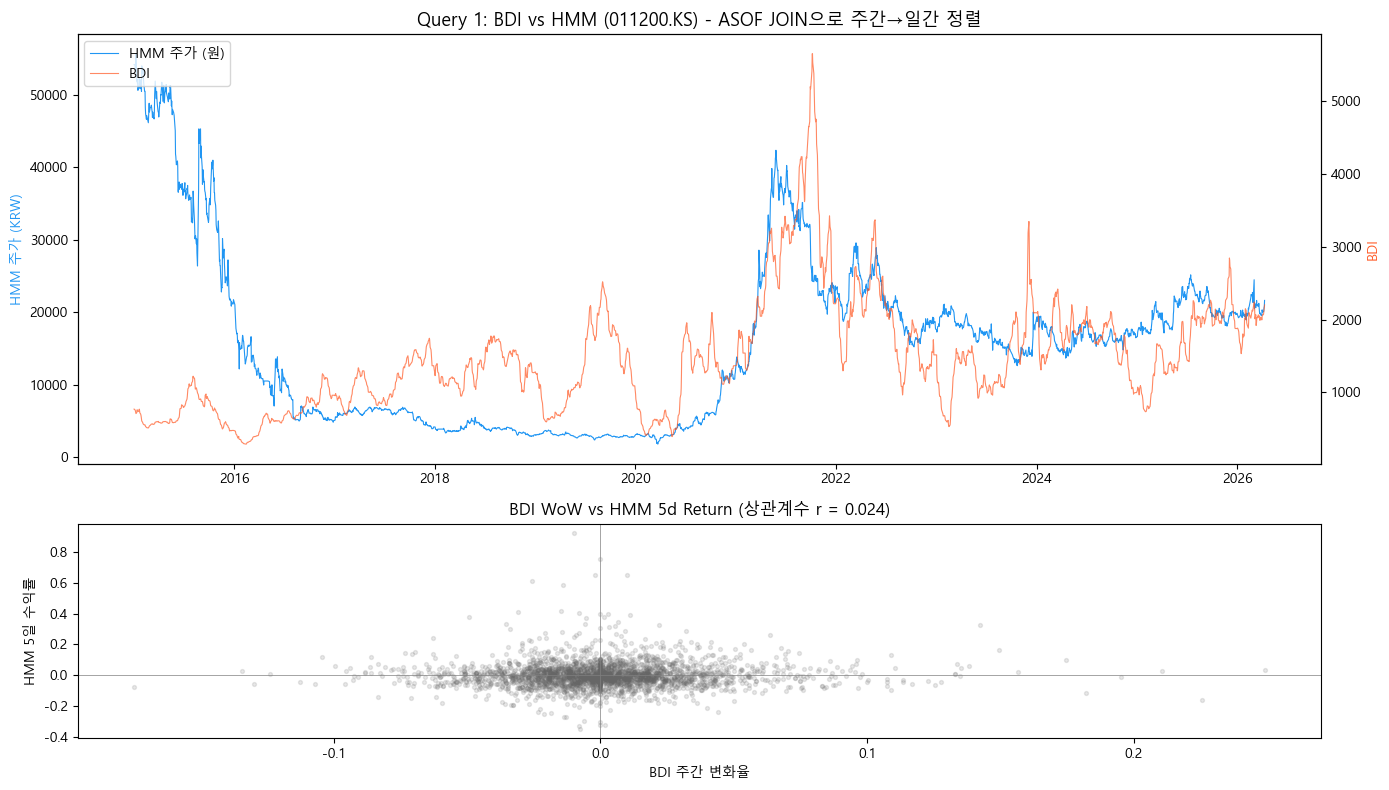

In [8]:
df1 = con.execute('''
    WITH bdi AS (
        SELECT observation_date, value AS bdi, pct_1p AS bdi_wow
        FROM v_indicator_changes WHERE indicator_id = 'BDI'
    ),
    hmm AS (
        SELECT date, adj_close, ret_5d
        FROM v_price_returns WHERE security_id = '011200.KS'
    )
    SELECT hmm.date, hmm.adj_close AS hmm_price, bdi.bdi, hmm.ret_5d, bdi.bdi_wow
    FROM hmm
    ASOF LEFT JOIN bdi ON bdi.observation_date <= hmm.date
    WHERE hmm.date >= DATE '2015-01-01'
    ORDER BY hmm.date
''').df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])

# 상단: BDI와 HMM 주가 (이중 축)
ax1.plot(df1['date'], df1['hmm_price'], color='#2196F3', linewidth=0.8, label='HMM 주가 (원)')
ax1.set_ylabel('HMM 주가 (KRW)', color='#2196F3')
ax1b = ax1.twinx()
ax1b.plot(df1['date'], df1['bdi'], color='#FF5722', linewidth=0.8, alpha=0.7, label='BDI')
ax1b.set_ylabel('BDI', color='#FF5722')
ax1.set_title('Query 1: BDI vs HMM (011200.KS) - ASOF JOIN으로 주간→일간 정렬', fontsize=13)
lines1 = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lines1, [l.get_label() for l in lines1], loc='upper left')

# 하단: 산점도 (BDI 주간 변화 vs HMM 5일 수익률)
valid = df1.dropna(subset=['bdi_wow', 'ret_5d'])
ax2.scatter(valid['bdi_wow'], valid['ret_5d'], alpha=0.15, s=8, color='#666')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
corr = valid['bdi_wow'].corr(valid['ret_5d'])
ax2.set_xlabel('BDI 주간 변화율')
ax2.set_ylabel('HMM 5일 수익률')
ax2.set_title(f'BDI WoW vs HMM 5d Return (상관계수 r = {corr:.3f})')
plt.tight_layout()
plt.show()

## Query 2: DRAM 현물가격 vs SK하이닉스 (2년 리베이스)

**핵심 개념: 리베이스(Rebase) 비교**

서로 다른 단위의 시계열을 시작점=1.0으로 리베이스하면 상대적 변화를 직접 비교할 수 있습니다.
CFM DRAM Index(주간)와 SK하이닉스 주가(일간)를 ASOF JOIN으로 정렬한 후 리베이스합니다.

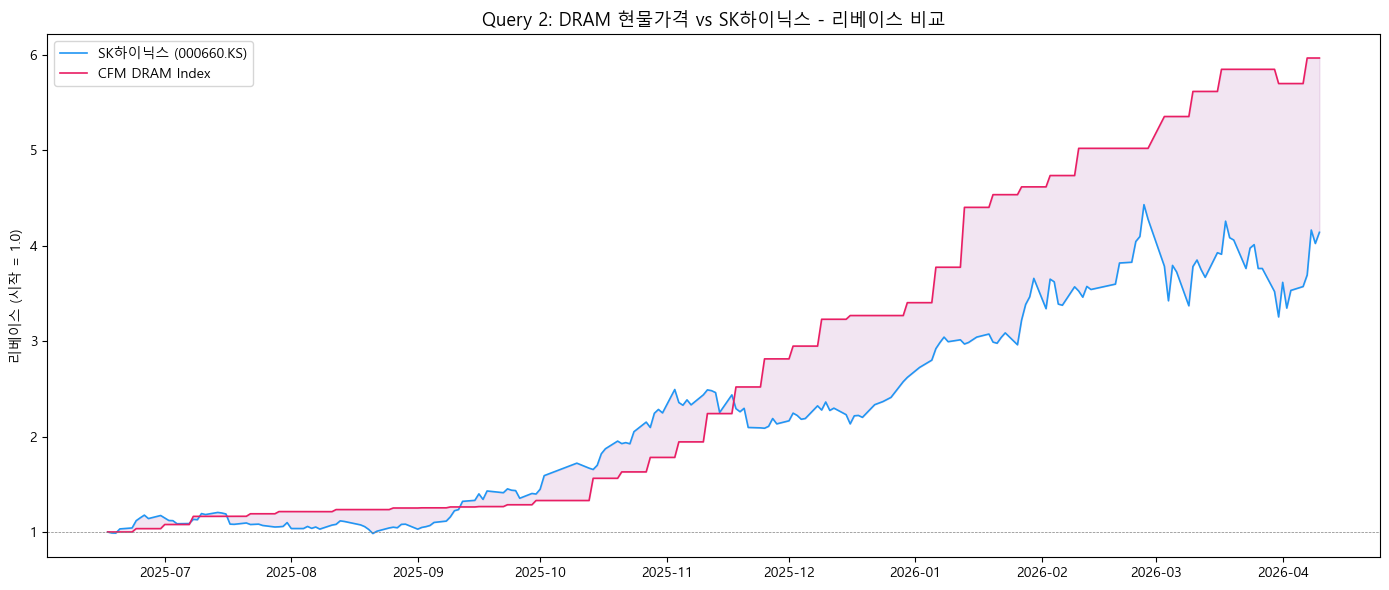

리베이스 상관계수: r = 0.962 (n = 200)


In [9]:
df2 = con.execute('''
    SELECT
        p.date,
        p.adj_close AS hynix,
        d.value AS dram_idx
    FROM fact_price p
    ASOF LEFT JOIN (
        SELECT observation_date, value
        FROM v_indicator_latest WHERE indicator_id = 'CFM_DRAM_INDEX'
    ) d ON d.observation_date <= p.date
    WHERE p.security_id = '000660.KS' AND d.value IS NOT NULL
    ORDER BY p.date
''').df()

# 리베이스 (시작점 = 1.0)
df2['hynix_rb'] = df2['hynix'] / df2['hynix'].iloc[0]
df2['dram_rb'] = df2['dram_idx'] / df2['dram_idx'].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df2['date'], df2['hynix_rb'], color='#2196F3', linewidth=1.2, label='SK하이닉스 (000660.KS)')
ax.plot(df2['date'], df2['dram_rb'], color='#E91E63', linewidth=1.2, label='CFM DRAM Index')
ax.axhline(1.0, color='gray', linewidth=0.5, linestyle='--')
ax.fill_between(df2['date'], df2['hynix_rb'], df2['dram_rb'], alpha=0.1, color='purple')
ax.set_ylabel('리베이스 (시작 = 1.0)')
ax.set_title('Query 2: DRAM 현물가격 vs SK하이닉스 - 리베이스 비교', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

corr = df2['hynix_rb'].corr(df2['dram_rb'])
print(f'리베이스 상관계수: r = {corr:.3f} (n = {len(df2):,})')

## Query 3: Point-in-Time 백테스트 - CPI vs SPY

**핵심 개념: Point-in-Time (PIT) 안전성**

CPI 1월 데이터는 2월 13일에 발표됩니다. 1월 31일에 이 값을 사용하면 **미래 정보 누수**입니다.
`v_indicator_pit` 뷰는 `effective_release_date`를 계산하여 **실제 공개 시점** 이후에만 값을 사용합니다.

아래 차트에서 CPI 값이 계단 형태로 변하는 것은 PIT가 정상 작동하는 증거입니다:
발표일까지는 이전 값이 유지되다가, 발표일에 새 값으로 갱신됩니다.

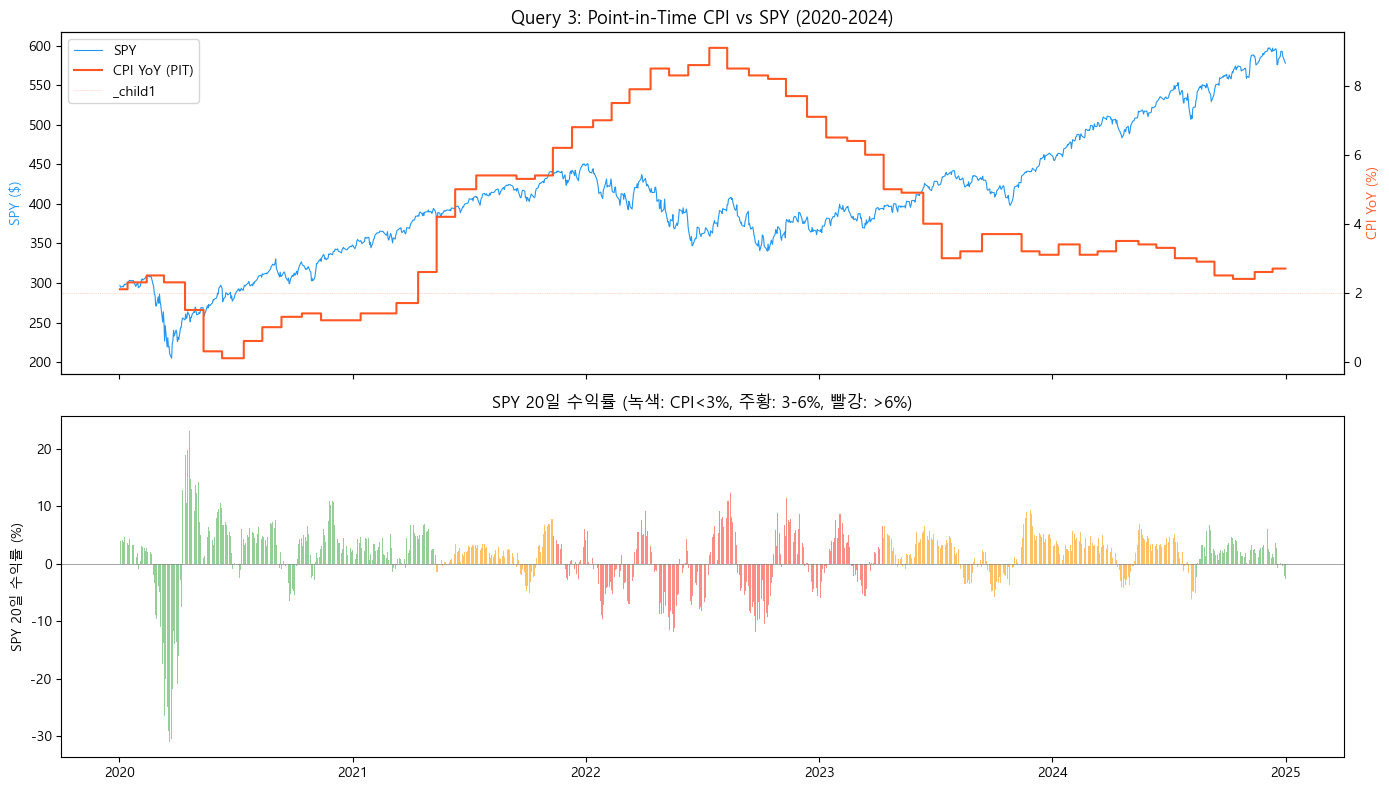

In [10]:
df3 = con.execute('''
    WITH cpi_pit AS (
        SELECT effective_release_date AS known_on, value AS cpi_yoy
        FROM v_indicator_pit WHERE indicator_id = 'US_CPI_YOY'
    ),
    spy AS (
        SELECT date, adj_close, ret_20d
        FROM v_price_returns WHERE security_id = 'SPY'
    )
    SELECT spy.date, spy.adj_close, spy.ret_20d, cpi.cpi_yoy
    FROM spy
    ASOF LEFT JOIN cpi_pit cpi ON cpi.known_on <= spy.date
    WHERE spy.date BETWEEN DATE '2020-01-01' AND DATE '2024-12-31'
    ORDER BY spy.date
''').df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 상단: SPY와 CPI (이중 축)
ax1.plot(df3['date'], df3['adj_close'], color='#2196F3', linewidth=0.8, label='SPY')
ax1.set_ylabel('SPY ($)', color='#2196F3')
ax1c = ax1.twinx()
ax1c.plot(df3['date'], df3['cpi_yoy'] * 100, color='#FF5722', linewidth=1.5,
          drawstyle='steps-post', label='CPI YoY (PIT)')
ax1c.set_ylabel('CPI YoY (%)', color='#FF5722')
ax1c.axhline(2.0, color='#FF5722', linewidth=0.5, linestyle=':', alpha=0.5)
ax1.set_title('Query 3: Point-in-Time CPI vs SPY (2020-2024)', fontsize=13)
lines = ax1.get_lines() + ax1c.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')

# 하단: SPY 20일 수익률을 CPI 레벨별로 색상 구분
colors = ['#4CAF50' if c < 0.03 else '#FF9800' if c < 0.06 else '#F44336'
          for c in df3['cpi_yoy'].fillna(0)]
ax2.bar(df3['date'], df3['ret_20d'] * 100, color=colors, width=1, alpha=0.6)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel('SPY 20일 수익률 (%)')
ax2.set_title('SPY 20일 수익률 (녹색: CPI<3%, 주황: 3-6%, 빨강: >6%)')
plt.tight_layout()
plt.show()

## Query 4: OFR 금융 스트레스 레짐 분석

**핵심 개념: 레짐 탐지 (Regime Detection)**

OFR Financial Stress Index의 z-score를 기준으로 시장을 3개 레짐으로 분류합니다:
- **stress_high** (z > 2): 극단적 스트레스 구간
- **normal** (-1 < z < 2): 정상 구간
- **stress_low** (z < -1): 안정 구간

각 레짐에서의 S&P 500 **향후 20일 수익률**을 비교합니다.

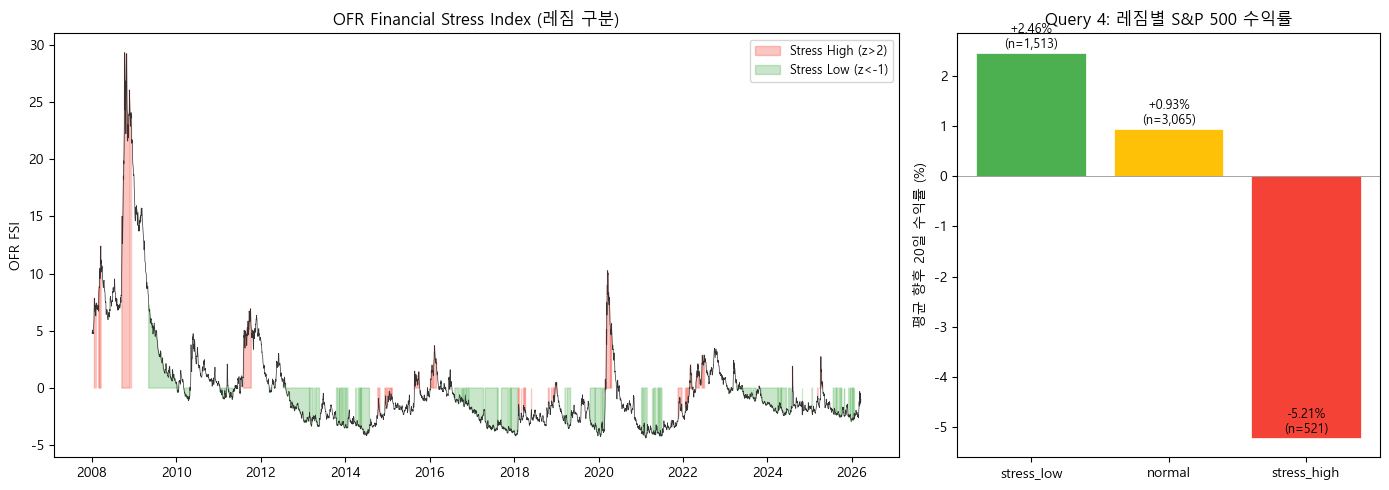

,regime,n,mean_20d_pct,vol_20d_pct
0,stress_low,1513,2.46,2.31
1,normal,3065,0.93,4.14
2,stress_high,521,-5.21,6.47


In [11]:
# 레짐별 통계
df4_stats = con.execute('''
    WITH stress AS (
        SELECT observation_date, value,
            AVG(value) OVER w AS mu, STDDEV(value) OVER w AS sigma
        FROM v_indicator_latest WHERE indicator_id = 'OFR_FSI'
        WINDOW w AS (ORDER BY observation_date ROWS BETWEEN 251 PRECEDING AND CURRENT ROW)
    ),
    stress_flag AS (
        SELECT observation_date,
            CASE WHEN (value - mu) / NULLIF(sigma, 0) > 2 THEN 'stress_high'
                 WHEN (value - mu) / NULLIF(sigma, 0) < -1 THEN 'stress_low'
                 ELSE 'normal' END AS regime
        FROM stress
    ),
    sp AS (SELECT date, ret_20d FROM v_price_returns WHERE security_id = '^GSPC')
    SELECT s.regime, COUNT(*) AS n,
           ROUND(AVG(k.ret_20d) * 100, 2) AS mean_20d_pct,
           ROUND(STDDEV(k.ret_20d) * 100, 2) AS vol_20d_pct
    FROM sp k ASOF LEFT JOIN stress_flag s ON s.observation_date <= k.date
    WHERE s.regime IS NOT NULL
    GROUP BY s.regime ORDER BY mean_20d_pct DESC
''').df()

# 시계열 데이터 (배경 색상용)
df4_ts = con.execute('''
    WITH stress AS (
        SELECT observation_date, value,
            AVG(value) OVER w AS mu, STDDEV(value) OVER w AS sigma
        FROM v_indicator_latest WHERE indicator_id = 'OFR_FSI'
        WINDOW w AS (ORDER BY observation_date ROWS BETWEEN 251 PRECEDING AND CURRENT ROW)
    )
    SELECT observation_date AS date, value AS ofr,
        (value - mu) / NULLIF(sigma, 0) AS z_score
    FROM stress WHERE observation_date >= DATE '2008-01-01'
    ORDER BY observation_date
''').df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})

# 좌: OFR FSI 시계열 + 레짐 하이라이트
ax1.plot(df4_ts['date'], df4_ts['ofr'], color='#333', linewidth=0.5)
ax1.fill_between(df4_ts['date'], df4_ts['ofr'], 0,
                 where=df4_ts['z_score'] > 2, color='#F44336', alpha=0.3, label='Stress High (z>2)')
ax1.fill_between(df4_ts['date'], df4_ts['ofr'], 0,
                 where=df4_ts['z_score'] < -1, color='#4CAF50', alpha=0.3, label='Stress Low (z<-1)')
ax1.set_title('OFR Financial Stress Index (레짐 구분)', fontsize=12)
ax1.set_ylabel('OFR FSI')
ax1.legend(fontsize=9)

# 우: 레짐별 Forward 20d Return 막대 차트
colors_bar = {'stress_low': '#4CAF50', 'normal': '#FFC107', 'stress_high': '#F44336'}
bars = ax2.bar(df4_stats['regime'], df4_stats['mean_20d_pct'],
               color=[colors_bar.get(r, '#999') for r in df4_stats['regime']],
               edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel('평균 향후 20일 수익률 (%)')
ax2.set_title('Query 4: 레짐별 S&P 500 수익률', fontsize=12)
for bar, row in zip(bars, df4_stats.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{row.mean_20d_pct:+.2f}%\n(n={row.n:,})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

display(df4_stats)

## Query 5: CNN Fear & Greed 선행지표 분석

**핵심 개념: Lead-Lag 분석**

CNN Fear & Greed Index를 5개 구간(0-20: 극도 공포 ~ 80-100: 극도 탐욕)으로 나누고,
각 구간에서 SPY의 **향후 5일 수익률**을 비교합니다.

"남들이 공포에 떨 때 매수하라" (워런 버핏)는 데이터로 검증 가능할까요?

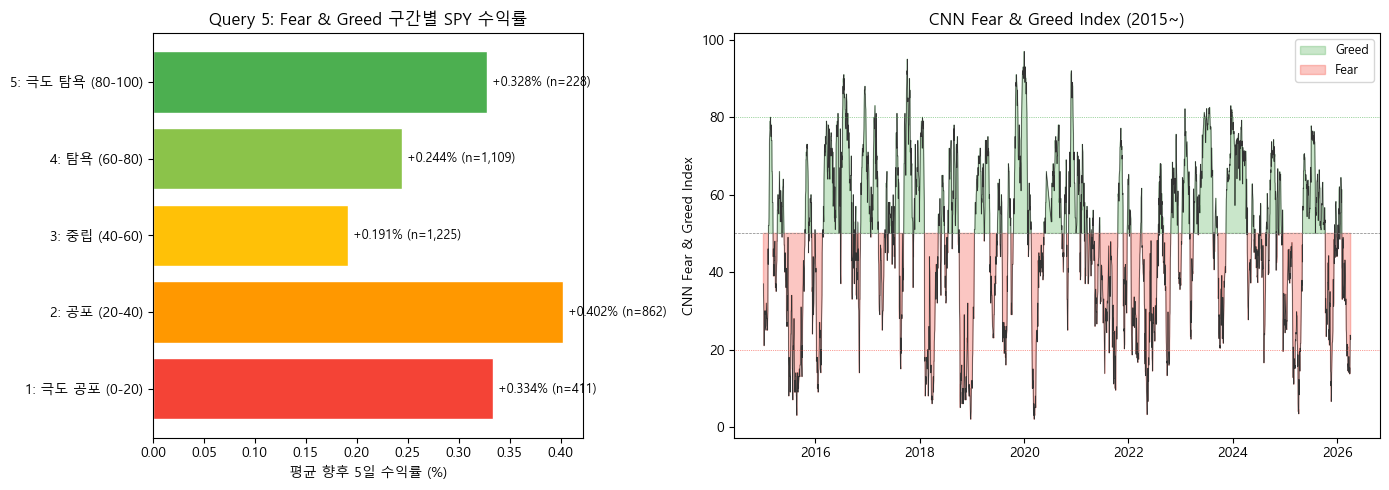

In [12]:
df5 = con.execute('''
    WITH fg AS (
        SELECT observation_date, value AS fear_greed
        FROM v_indicator_latest WHERE indicator_id = 'CNN_FEAR_GREED'
    ),
    spy_fwd AS (
        SELECT date, adj_close,
            LEAD(adj_close, 5) OVER (ORDER BY date) / adj_close - 1 AS fwd_5d
        FROM fact_price WHERE security_id = 'SPY'
    )
    SELECT s.date, fg.fear_greed, s.fwd_5d,
        CASE WHEN fg.fear_greed < 20 THEN '1: 극도 공포 (0-20)'
             WHEN fg.fear_greed < 40 THEN '2: 공포 (20-40)'
             WHEN fg.fear_greed < 60 THEN '3: 중립 (40-60)'
             WHEN fg.fear_greed < 80 THEN '4: 탐욕 (60-80)'
             ELSE '5: 극도 탐욕 (80-100)' END AS bucket
    FROM spy_fwd s
    ASOF JOIN fg ON fg.observation_date <= s.date
    WHERE s.fwd_5d IS NOT NULL
''').df()

# 버킷별 통계
stats5 = df5.groupby('bucket')['fwd_5d'].agg(['mean', 'std', 'count']).reset_index()
stats5['mean_pct'] = stats5['mean'] * 100
stats5['std_pct'] = stats5['std'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.5]})

# 좌: 버킷별 평균 수익률
colors_fg = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
bars = ax1.barh(stats5['bucket'], stats5['mean_pct'], color=colors_fg, edgecolor='white')
ax1.axvline(0, color='gray', linewidth=0.5)
ax1.set_xlabel('평균 향후 5일 수익률 (%)')
ax1.set_title('Query 5: Fear & Greed 구간별 SPY 수익률', fontsize=12)
for bar, row in zip(bars, stats5.itertuples()):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{row.mean_pct:+.3f}% (n={row.count:,})', va='center', fontsize=9)

# 우: Fear & Greed 시계열
fg_ts = con.execute('''
    SELECT observation_date AS date, value FROM v_indicator_latest
    WHERE indicator_id = 'CNN_FEAR_GREED' AND observation_date >= DATE '2015-01-01'
    ORDER BY observation_date
''').df()
ax2.fill_between(fg_ts['date'], fg_ts['value'], 50, where=fg_ts['value'] >= 50,
                 color='#4CAF50', alpha=0.3, label='Greed')
ax2.fill_between(fg_ts['date'], fg_ts['value'], 50, where=fg_ts['value'] < 50,
                 color='#F44336', alpha=0.3, label='Fear')
ax2.plot(fg_ts['date'], fg_ts['value'], color='#333', linewidth=0.5)
ax2.axhline(50, color='gray', linewidth=0.5, linestyle='--')
ax2.axhline(20, color='#F44336', linewidth=0.5, linestyle=':')
ax2.axhline(80, color='#4CAF50', linewidth=0.5, linestyle=':')
ax2.set_ylabel('CNN Fear & Greed Index')
ax2.set_title('CNN Fear & Greed Index (2015~)', fontsize=12)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Query 6: 멀티 지표 패널 - 삼성전자 (005930.KS)

**핵심 개념: 다중 ASOF JOIN**

하나의 쿼리에서 여러 지표를 동시에 조합합니다.
각 지표는 서로 다른 주기(일간/주간/월간)이지만, `ASOF LEFT JOIN`으로 자연스럽게 정렬됩니다.

새로운 지표를 추가하려면 `ASOF LEFT JOIN` 한 줄만 추가하면 됩니다 - 스키마 변경 불필요!

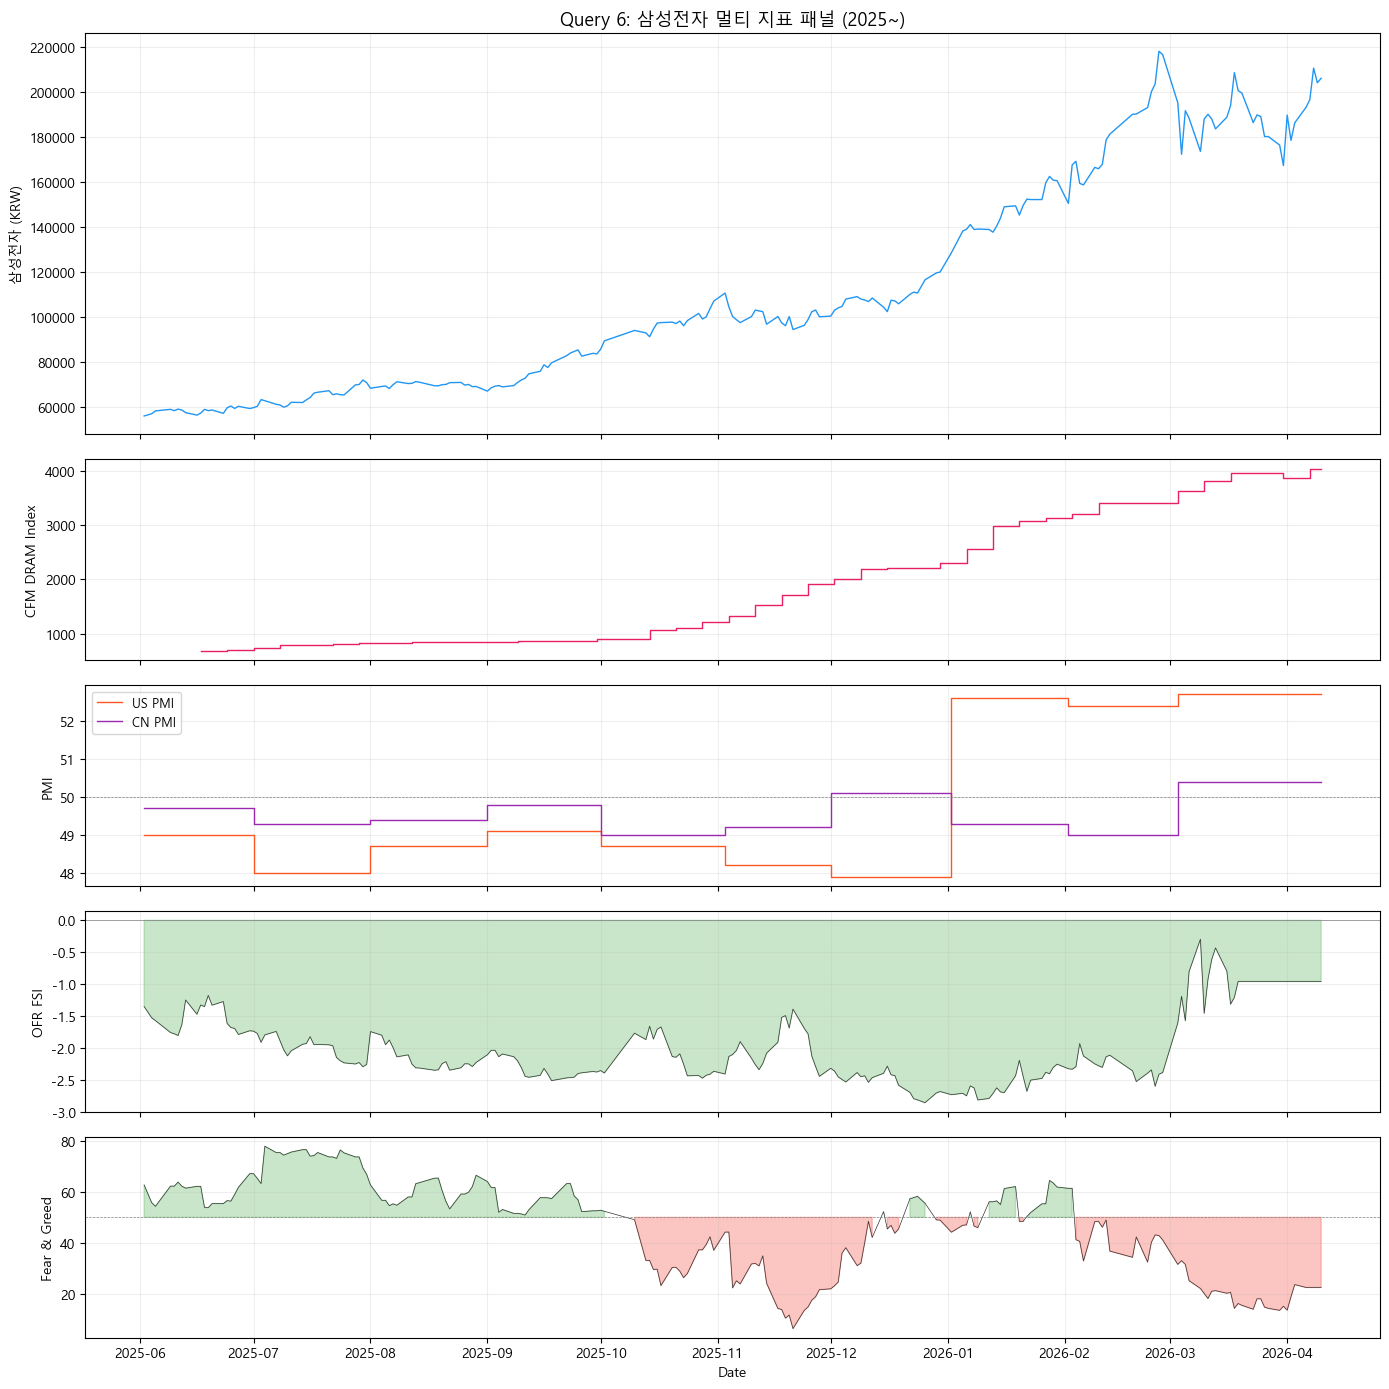

In [13]:
df6 = con.execute('''
    WITH base AS (
        SELECT date, adj_close, ret_5d
        FROM v_price_returns WHERE security_id = '005930.KS'
    )
    SELECT b.date, b.adj_close AS samsung, b.ret_5d,
        dram.value AS dram_idx,
        pmi.value AS us_pmi,
        cn_pmi.value AS cn_pmi,
        ofr.value AS ofr_fsi,
        fg.value AS fear_greed
    FROM base b
    ASOF LEFT JOIN (SELECT observation_date, value FROM v_indicator_latest
        WHERE indicator_id = 'CFM_DRAM_INDEX') dram ON dram.observation_date <= b.date
    ASOF LEFT JOIN (SELECT observation_date, value FROM v_indicator_latest
        WHERE indicator_id = 'US_PMI') pmi ON pmi.observation_date <= b.date
    ASOF LEFT JOIN (SELECT observation_date, value FROM v_indicator_latest
        WHERE indicator_id = 'CN_PMI') cn_pmi ON cn_pmi.observation_date <= b.date
    ASOF LEFT JOIN (SELECT observation_date, value FROM v_indicator_latest
        WHERE indicator_id = 'OFR_FSI') ofr ON ofr.observation_date <= b.date
    ASOF LEFT JOIN (SELECT observation_date, value FROM v_indicator_latest
        WHERE indicator_id = 'CNN_FEAR_GREED') fg ON fg.observation_date <= b.date
    WHERE b.date >= DATE '2025-06-01'
    ORDER BY b.date
''').df()

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1, 1, 1]})

# 1. 삼성전자 주가
axes[0].plot(df6['date'], df6['samsung'], color='#2196F3', linewidth=1)
axes[0].set_ylabel('삼성전자 (KRW)')
axes[0].set_title('Query 6: 삼성전자 멀티 지표 패널 (2025~)', fontsize=13)
axes[0].grid(alpha=0.2)

# 2. DRAM Index
axes[1].plot(df6['date'], df6['dram_idx'], color='#E91E63', linewidth=1, drawstyle='steps-post')
axes[1].set_ylabel('CFM DRAM Index')
axes[1].grid(alpha=0.2)

# 3. US PMI + CN PMI
axes[2].plot(df6['date'], df6['us_pmi'], color='#FF5722', linewidth=1, drawstyle='steps-post', label='US PMI')
axes[2].plot(df6['date'], df6['cn_pmi'], color='#9C27B0', linewidth=1, drawstyle='steps-post', label='CN PMI')
axes[2].axhline(50, color='gray', linewidth=0.5, linestyle='--')
axes[2].set_ylabel('PMI')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)

# 4. OFR FSI
axes[3].fill_between(df6['date'], df6['ofr_fsi'], 0, alpha=0.3,
                      color=['#F44336' if v > 0 else '#4CAF50' for v in df6['ofr_fsi'].fillna(0)])
axes[3].plot(df6['date'], df6['ofr_fsi'], color='#333', linewidth=0.5)
axes[3].axhline(0, color='gray', linewidth=0.5)
axes[3].set_ylabel('OFR FSI')
axes[3].grid(alpha=0.2)

# 5. CNN Fear & Greed
axes[4].fill_between(df6['date'], df6['fear_greed'], 50,
                      where=df6['fear_greed'] >= 50, color='#4CAF50', alpha=0.3)
axes[4].fill_between(df6['date'], df6['fear_greed'], 50,
                      where=df6['fear_greed'] < 50, color='#F44336', alpha=0.3)
axes[4].plot(df6['date'], df6['fear_greed'], color='#333', linewidth=0.5)
axes[4].axhline(50, color='gray', linewidth=0.5, linestyle='--')
axes[4].set_ylabel('Fear & Greed')
axes[4].set_xlabel('Date')
axes[4].grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
# 3. 자주 쓰는 쿼리 패턴 (Quick Reference)

아래 패턴을 복사해서 자신만의 분석에 활용하세요.

### 패턴 1: 단일 지표 시계열 조회
```sql
SELECT observation_date, value
FROM v_indicator_latest
WHERE indicator_id = 'BDI'  -- indicator_id를 변경
ORDER BY observation_date
```

### 패턴 2: 지표와 주가 ASOF JOIN
```sql
SELECT p.date, p.adj_close, ind.value AS indicator_value
FROM fact_price p
ASOF LEFT JOIN (
    SELECT observation_date, value FROM v_indicator_latest
    WHERE indicator_id = 'YOUR_INDICATOR'  -- 변경
) ind ON ind.observation_date <= p.date
WHERE p.security_id = '005930.KS'  -- 변경
ORDER BY p.date
```

### 패턴 3: Point-in-Time 안전한 조회
```sql
SELECT * FROM v_indicator_pit
WHERE indicator_id = 'US_CPI_YOY'
  AND effective_release_date <= DATE '2024-06-30'  -- 백테스트 기준일
```

### 패턴 4: 변화율 조회 (자동 주기 처리)
```sql
SELECT observation_date, value, pct_1p, diff_1p
FROM v_indicator_changes
WHERE indicator_id = 'BDI'  -- weekly면 주간변화, monthly면 월간변화
```

In [14]:
# 연결 종료
con.close()
print('Database connection closed.')

Database connection closed.
